## Causal inference example: Hillstrom E-mail campaign

Abstract

This notebook explores causal inference techniques using the Hillstrom Email Marketing dataset, which contains the results of a randomised email campaign. The analysis begins with naive estimates of campaign effectiveness and explores treatment effects across customer segments using pre-treatment covariates. Although the randomised design allows unbiased estimation of the average treatment effect (ATE) through simple treatment–control comparisons, the dataset also serves as a useful framework for demonstrating common causal inference methodologies used in observational settings.

The notebook proceeds to estimate propensity scores, assess covariate balance using standardised mean differences (SMD), and estimate treatment effects using propensity score matching (ATT) and inverse propensity weighting (ATE). Finally, heterogeneous treatment effects are explored using causal forests to estimate Conditional Average Treatment Effects (CATE), illustrating how treatment effects can vary across customers and how such estimates can be used to inform uplift-based targeting strategies.

The objective is not only to estimate whether the campaign was effective on average, but also to demonstrate a practical workflow for moving from average treatment effect estimation to customer-level treatment effect modelling and targeted intervention design.

In [1]:
import os
from copy import deepcopy

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

## The Hillstrom dataset

Contains 64000 customers who purchased in the 12 months prior. 1/3 were chosen to receive Mens Email campaign, 1/3 Womens campaign, and 1/3 no treatment.

- 'recency': number of months since last purchase (1-12)
- 'history_segment': bin of 12-month purchase history ('history')
- 'history': purchase history, in $
- 'mens', 'womens': customer purchased Mens/Womens merchandise in the past year
- 'zip_code': Urban or Suburban or Rural
- 'newbie': new customer in the past 12 months
- 'channel': customer purchase channel

Post-campaign (2 weeks after):

- 'segment': Treatment flag
- 'visit': boolean whether customer visited website
- 'conversion': boolean whether customer made any purchase
- 'spend': amount of spend in $

In [2]:
df = pd.read_csv('hillstrom.csv')
df['segment_'] = df['segment'].replace({
    'Mens E-Mail': '1_Mens E-Mail',
    'Womens E-Mail': '2_Womens E-Mail',
    'No E-Mail': '0_No E-Mail'
})

In [3]:
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,segment_
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0,2_Womens E-Mail
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0,0_No E-Mail
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0,2_Womens E-Mail
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0,1_Mens E-Mail
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0,2_Womens E-Mail


In [4]:
df.shape

(64000, 13)

In [5]:
df.columns

Index(['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code',
       'newbie', 'channel', 'segment', 'visit', 'conversion', 'spend',
       'segment_'],
      dtype='object')

In [6]:
pretreat_cols = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code',
       'newbie', 'channel']
treat_flag = 'segment_'
postreat_cols = ['spend', 'conversion', 'visit']

## Global statistics

### Treatment flag

In [7]:
df['segment_'].value_counts()

segment_
2_Womens E-Mail    21387
1_Mens E-Mail      21307
0_No E-Mail        21306
Name: count, dtype: int64

### Pre-treatment variables

In [8]:
df[pretreat_cols].describe()

,recency,history,mens,womens,newbie
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250
std,3.507592,256.158608,0.497393,0.497526,0.499999
min,1.000000,29.990000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000


<Axes: xlabel='zip_code'>

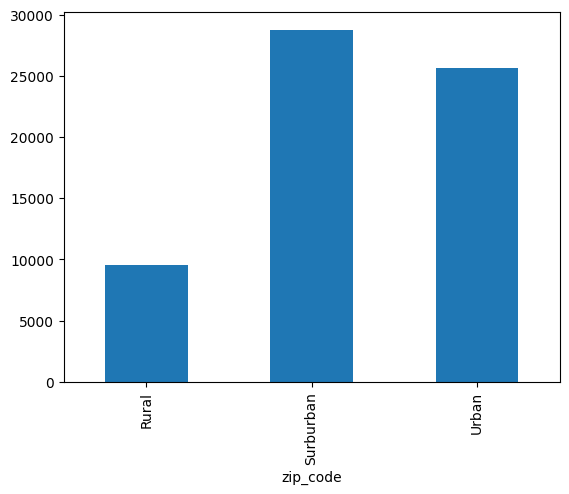

In [9]:
df['zip_code'].value_counts().sort_index().plot.bar()

<Axes: xlabel='channel'>

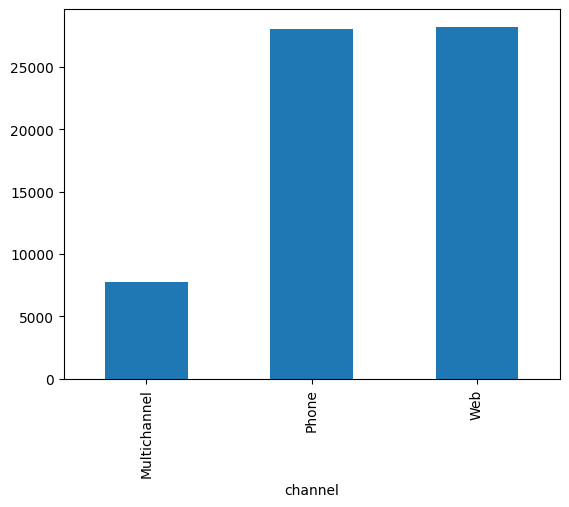

In [10]:
df['channel'].value_counts().sort_index().plot.bar()

<Axes: >

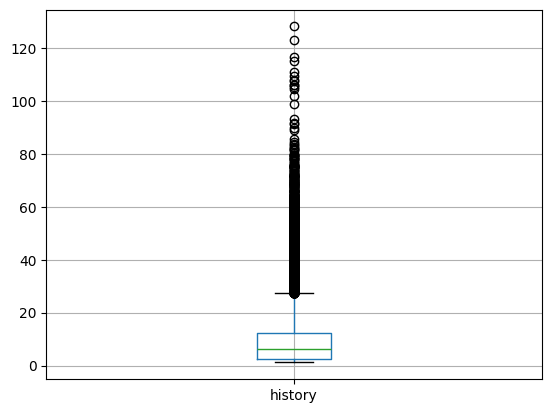

In [11]:
(df[['history']] / (365.25/14)).boxplot()

Historical spend averged to 2-weekly has long tail

In [12]:
df['history_segment'].value_counts()

history_segment
1) $0 - $100        22970
2) $100 - $200      14254
3) $200 - $350      12289
4) $350 - $500       6409
5) $500 - $750       4911
6) $750 - $1,000     1859
7) $1,000 +          1308
Name: count, dtype: int64

Naively, the numerical pre-treatment variables are reasonably evenly distributed especially the boolean flags. Rural and multi-channel are less frequent.

### Post-treatment variables

In [13]:
df[postreat_cols].describe()

,spend,conversion,visit
count,64000.000000,64000.000000,64000.000000
mean,1.050908,0.009031,0.146781
std,15.036448,0.094604,0.353890
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,499.000000,1.000000,1.000000


Spend distribution excluding non-converted:

<Axes: >

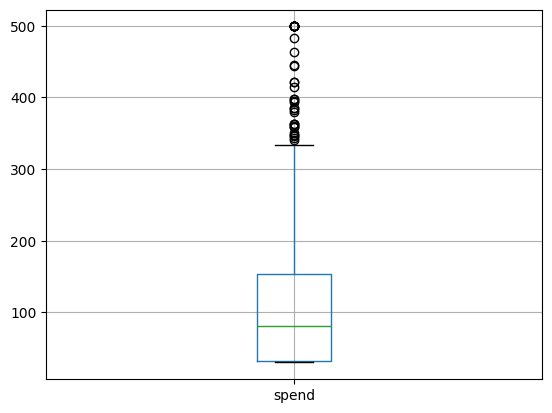

In [14]:
df[df['conversion'] == 1][['spend']].boxplot()

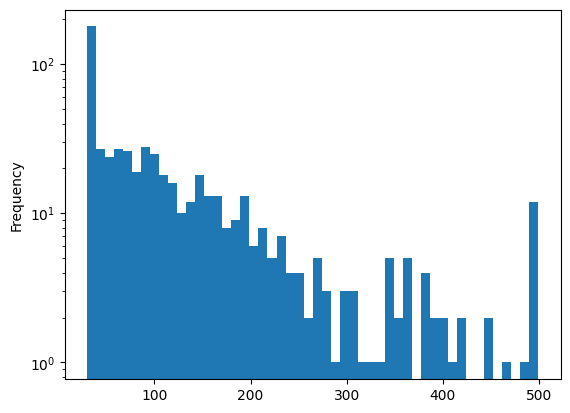

In [15]:
df[df['conversion'] == 1]['spend'].plot.hist(bins=50)
plt.yscale('log')

Globally, the post-treatment spend is mostly below $150, with a long tail.

## Pre-treatment covariates by treatment group

In [16]:
pretreat_cols

['recency',
 'history_segment',
 'history',
 'mens',
 'womens',
 'zip_code',
 'newbie',
 'channel']

In [17]:
df.groupby(treat_flag).agg({
    col: ['mean', 'median', 'std'] for col in pretreat_cols if df[col].dtype in ['int64', 'float64']
}).sort_index()

recency                      history                       \
                     mean median       std        mean   median         std   
segment_                                                                      
0_No E-Mail      5.749695    5.0  3.497517  240.882653  156.655  252.739362   
1_Mens E-Mail    5.773642    6.0  3.513350  242.835931  157.220  260.355685   
2_Womens E-Mail  5.767850    6.0  3.511989  242.536633  160.090  255.332880   

                     mens                     womens                   \
                     mean median       std      mean median       std   
segment_                                                                
0_No E-Mail      0.553224    1.0  0.497171  0.547639    1.0  0.497737   
1_Mens E-Mail    0.550946    1.0  0.497409  0.551415    1.0  0.497361   
2_Womens E-Mail  0.548932    1.0  0.497612  0.550101    1.0  0.497495   

                   newbie                   
                     mean median       std  
segment_                                    
0_No E-Mail      0.501971    1.0  0.500008  
1_Mens E-Mail    0.501525    1.0  0.500009  
2_Womens E-Mail  0.503250    1.0  0.500001

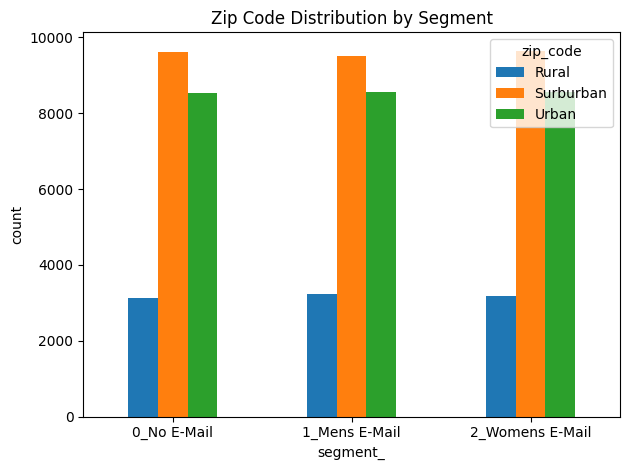

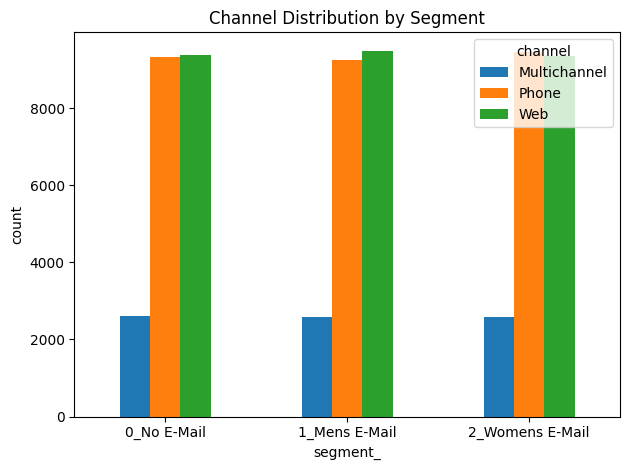

In [18]:
df.groupby(treat_flag)['zip_code'].value_counts().unstack().plot(kind='bar')
plt.ylabel('count')
plt.title('Zip Code Distribution by Segment')
plt.xticks(rotation=0)
plt.legend(title='zip_code')
plt.tight_layout()
plt.show()

df.groupby(treat_flag)['channel'].value_counts().unstack().plot(kind='bar')
plt.ylabel('count')
plt.title('Channel Distribution by Segment')
plt.xticks(rotation=0)
plt.legend(title='channel')
plt.tight_layout()
plt.show()

On face value, the pre-treatment covariates follow similar distributions in each group, at least qualitatively.

## Naive treatment effect estimates

Post-treatment variables

In [19]:
df.groupby([treat_flag]).agg({
    'spend': ['mean', 'median', 'std'],
    'conversion': ['mean', 'median', 'std'],
    'visit': ['mean', 'median', 'std']
}).sort_index()

spend                   conversion                   \
                     mean median        std       mean median       std   
segment_                                                                  
0_No E-Mail      0.652789    0.0  11.588200   0.005726    0.0  0.075456   
1_Mens E-Mail    1.422617    0.0  17.754205   0.012531    0.0  0.111241   
2_Womens E-Mail  1.077202    0.0  15.116106   0.008837    0.0  0.093592   

                    visit                   
                     mean median       std  
segment_                                    
0_No E-Mail      0.106167    0.0  0.308059  
1_Mens E-Mail    0.182757    0.0  0.386476  
2_Womens E-Mail  0.151400    0.0  0.358447

Text(0.5, 1.0, 'Visit Rate by Segment')

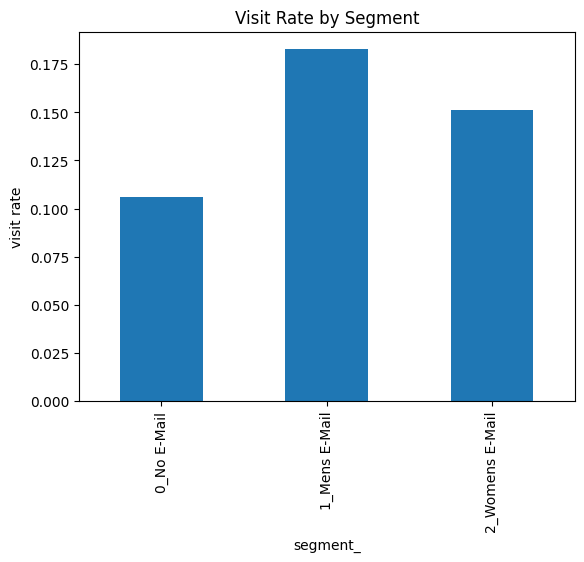

In [20]:
visit_rate = df.groupby(treat_flag)['visit'].mean()
visit_rate.plot.bar()
plt.ylabel('visit rate')
plt.title('Visit Rate by Segment')

Text(0.5, 1.0, 'Conversion Rate by Segment')

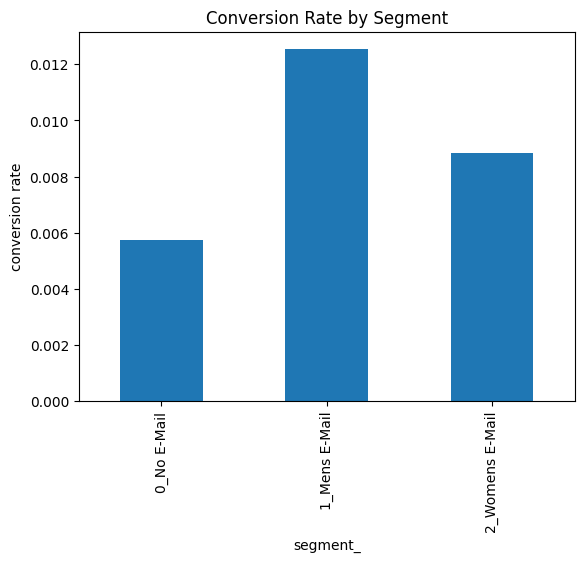

In [21]:
conversion_rate = df.groupby(treat_flag)['conversion'].mean()
conversion_rate.plot.bar()
plt.ylabel('conversion rate')
plt.title('Conversion Rate by Segment')

<Axes: title={'center': 'spend'}, xlabel='segment_'>

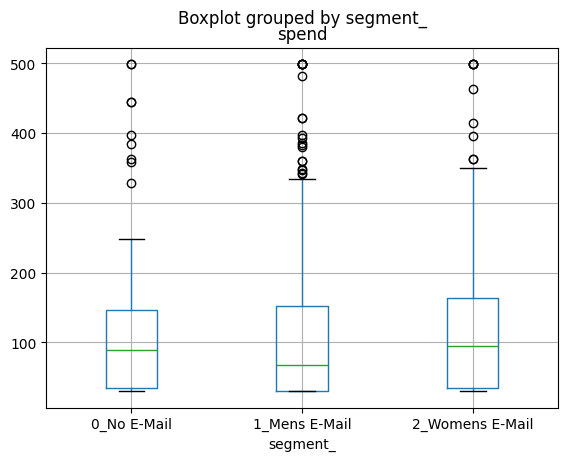

In [22]:
df[df['conversion']==1].boxplot(column='spend', by=treat_flag)

### Naive Average Treatment Effect (ATE)

#### Global treatment effects

In [23]:
ate_naive_global = df[treat_flag].drop_duplicates().sort_values().to_frame()
for col in postreat_cols:
    ate_ = df.groupby(treat_flag)[col].mean()
    ate_ = (ate_ - ate_.loc['0_No E-Mail']).reset_index()
    ate_naive_global = ate_naive_global.merge(ate_, on=treat_flag, how='left')

In [24]:
ate_naive_global

,segment_,spend,conversion,visit
0,0_No E-Mail,0.000000,0.000000,0.000000
1,1_Mens E-Mail,0.769827,0.006805,0.076590
2,2_Womens E-Mail,0.424412,0.003111,0.045233


Naively, the global ATE appears positive on all post-treatment metrics, with Mens Email campaign having the largest positive impact.

#### Naive ATE by groups

In [25]:
def ate_by_pretreat_col(df, pretreat_col):
    ate_naive = []
    for pretreat_val in sorted(df[pretreat_col].unique()):
        subset = df[df[pretreat_col] == pretreat_val]
        ate_ = subset.groupby(treat_flag)[postreat_cols].mean()
        ate_ = (ate_ - ate_.loc['0_No E-Mail']).reset_index()
        ate_[pretreat_col] = pretreat_val
        ate_naive.append(ate_)

    ate_naive = pd.concat(ate_naive, ignore_index=True)
    ate_naive = ate_naive[ate_naive[treat_flag] != '0_No E-Mail']
    ate_naive = ate_naive[[
        treat_flag, pretreat_col
        ] + postreat_cols].sort_values(by=[treat_flag, pretreat_col])
    return ate_naive

In [26]:
ate_by_pretreat_col(df, 'newbie')

,segment_,newbie,spend,conversion,visit
1,1_Mens E-Mail,0,0.577967,0.006207,0.077833
4,1_Mens E-Mail,1,0.960020,0.007396,0.075305
2,2_Womens E-Mail,0,0.113957,0.000932,0.040123
5,2_Womens E-Mail,1,0.732288,0.005272,0.050417


Treatments appear to be positive on both newbie and non-newbie, and have larger impact on newbies in terms of spend, conversion and visit, except for visit and Mens Email.

In [27]:
ate_by_pretreat_col(df, 'history_segment')

,segment_,history_segment,spend,conversion,visit
1,1_Mens E-Mail,1) $0 - $100,0.538283,0.004988,0.068552
4,1_Mens E-Mail,2) $100 - $200,0.704249,0.004818,0.069110
7,1_Mens E-Mail,3) $200 - $350,0.536581,0.008480,0.084398
10,1_Mens E-Mail,4) $350 - $500,1.568940,0.008729,0.089201
13,1_Mens E-Mail,5) $500 - $750,1.103010,0.008328,0.098952
16,1_Mens E-Mail,"6) $750 - $1,000",1.534146,0.020022,0.061498
19,1_Mens E-Mail,"7) $1,000 +",1.322067,0.009284,0.097066
2,2_Womens E-Mail,1) $0 - $100,0.625820,0.003787,0.046782
5,2_Womens E-Mail,2) $100 - $200,0.458393,0.003692,0.042504
8,2_Womens E-Mail,3) $200 - $350,-0.323141,-0.000666,0.036095


Mens Email appears to have positive impact on all history segments; effect on conversion largest on `6) $750 - $1,000`, and on spend the higher segment brackets.
Womens Email appears to have mixed impact over history segments; effect on spend and conversion negative on `3) $200 - $350` and `4) $350 - $500`. Largest effect on spend in `7) $1,000 +`.


In [28]:
ate_by_pretreat_col(df, 'zip_code')

,segment_,zip_code,spend,conversion,visit
1,1_Mens E-Mail,Rural,0.755500,0.005285,0.073398
4,1_Mens E-Mail,Surburban,0.803848,0.007433,0.074337
7,1_Mens E-Mail,Urban,0.736507,0.006643,0.079641
2,2_Womens E-Mail,Rural,0.514841,0.003349,0.029095
5,2_Womens E-Mail,Surburban,0.177171,0.002578,0.048863
8,2_Womens E-Mail,Urban,0.669135,0.003614,0.046943


Womens Email has less spend effect on `Surburban` customers.

In [29]:
ate_by_pretreat_col(df, 'channel')

,segment_,channel,spend,conversion,visit
1,1_Mens E-Mail,Multichannel,1.209129,0.010167,0.082937
4,1_Mens E-Mail,Phone,0.564074,0.005462,0.075604
7,1_Mens E-Mail,Web,0.850449,0.007200,0.075563
2,2_Womens E-Mail,Multichannel,1.157536,0.007052,0.047100
5,2_Womens E-Mail,Phone,0.232474,0.001726,0.044630
8,2_Womens E-Mail,Web,0.416317,0.003433,0.045677


All positive, but larger effect on `Multichannel` customers, least on `Phone` channel customers.

Text(0, 0.5, 'ATE spend')

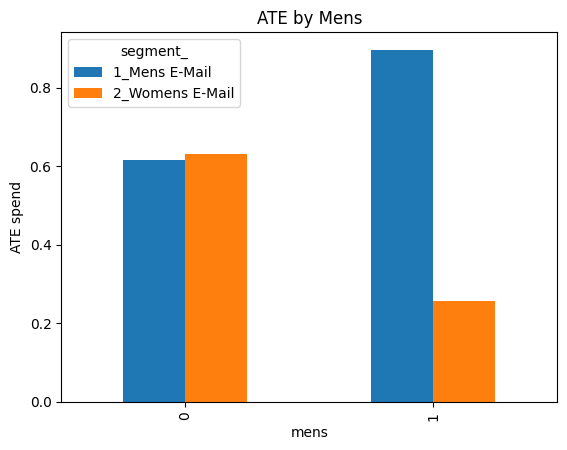

In [30]:
ate_by_mens = ate_by_pretreat_col(df, 'mens')
ate_by_mens.pivot(index='mens', columns=treat_flag, values='spend') \
    .plot(kind='bar', title='ATE by Mens')
plt.ylabel('ATE spend')

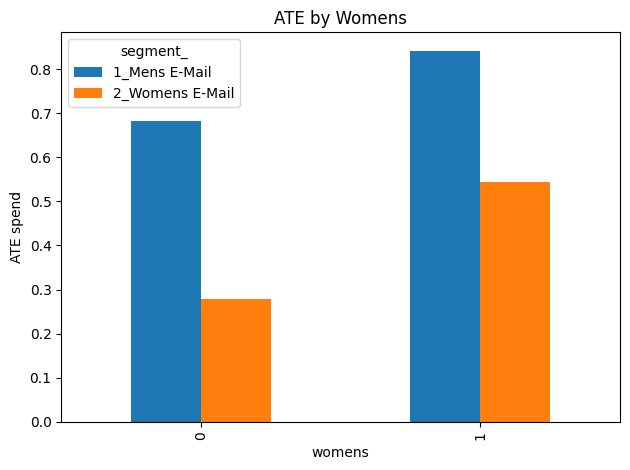

In [31]:
ate_by_womens = ate_by_pretreat_col(df, 'womens')
ate_by_womens.pivot(index='womens', columns=treat_flag, values='spend') \
    .plot(kind='bar', title='ATE by Womens')
plt.ylabel('ATE spend')
plt.tight_layout()

Womens Email has noticeably less effect on customers who made `mens` past purchase. Mens email has larger effect on customers who made `mens` past purchase.

Both campaigns have less effect on those who made no `womens` past purchase.

### Naive ATE analysis summary: 

- Naive ATE summary:
    - Mens Email: roughly +0.77 spend, +0.0068 conversion, +0.0766 visit.
    - Womens Email: roughly +0.42 spend, +0.0031 conversion, +0.0452 visit.

- Pretreatment covariate heterogeneity:
    - Newbie: both campaigns positive; effects are larger for newbies, especially spend and conversion.
    - History segment: Mens Email positive across all history buckets and especially strong in higher spend segments; Womens Email is mixed, with negative or small effects in mid-range history buckets and much stronger positive spend effect in the highest history segment.
    - Zip code: Mens Email is fairly consistent across Rural/Suburban/Urban; Womens Email is weakest in Suburban and relatively stronger in Urban and Rural.
    - Channel: both campaigns have the largest impact for Multichannel customers and the smallest impact for Phone customers.
    - Prior mens purchase: Mens Email is more effective for customers who previously bought mens merchandise; Womens Email is less effective for those same customers.
    - Prior womens purchase: both campaigns tend to have larger effects for customers who previously bought womens merchandise, with Womens Email showing the biggest difference.
    - Recency: Mens Email is generally positive across recency values; Womens Email is more variable, with some recency groups showing little or even negative spend effect.

## Treatment Effect by Propensity Score Matching (PSM)

We have seen from the previous naive ATE analysis that, although globally both Email campaigns appear to have positive effects, ATEs by pre-treatment covariate show heterogeneity. We also found that, qualitatively, the treatment/control groups appear more or less randomised in terms of the distributions of the pre-treatment covariate.

But the latter was just a qualitative observation. Given the small naive ATE of both campaigns, it is crucial now to take into account the quantitative differences of pre-treatment covariates to be certain of the actual treatment effects because they may have biased the ATE we saw. We use Propensity Score Matching (PSM) to de-bias the treatment effect metrics. Propensity score methods attempt to balance observed covariates so that treated and control customers become more comparable, approximating the conditions of a randomised experiment.

To keep things simple, we combine the Mens and Womens treatments.

In [32]:
df['segment1'] = df['segment'].replace({
    'Mens E-Mail': 1,
    'Womens E-Mail': 1,
    'No E-Mail': 0
})

/tmp/ipykernel_114429/2189207449.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['segment1'] = df['segment'].replace({


In [33]:
treat_flag1 = 'segment1'

### Fit propensity score model

In [34]:
pretreat_cols_psm = [
    'recency',
    # 'history_segment',
    'history',
    'mens',
    'womens',
    # 'zip_code',
    'newbie',
    # 'channel'
    ]

In [35]:
X = df[pretreat_cols_psm].copy()
obj_cols = X.select_dtypes(include=['object']).columns
X[obj_cols] = X[obj_cols].apply(lambda s: s.astype('category'))

In [36]:
ps_model = XGBClassifier(random_state=42, enable_categorical=True)
ps_model.fit(X, df[treat_flag1])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [37]:
df["propensity_score"] = ps_model.predict_proba(X)[:, 1]

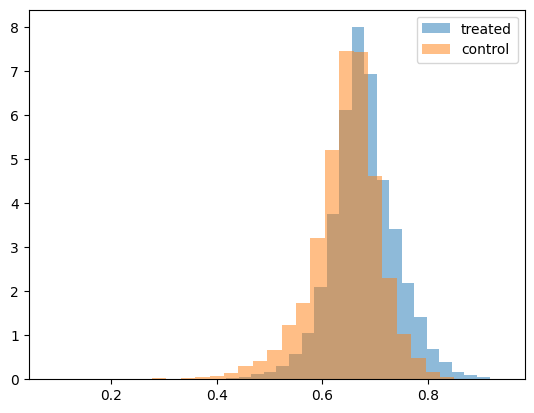

In [38]:
# verify large overlap in propensity scores between treated and control groups
plt.hist(
    df.loc[df[treat_flag1] == 1, "propensity_score"],
    bins=30,
    alpha=0.5,
    label="treated",
    density=True
)

plt.hist(
    df.loc[df[treat_flag1] == 0, "propensity_score"],
    bins=30,
    alpha=0.5,
    label="control",
    density=True
)

plt.legend()
plt.show()

### Quantifying treatment group covariate difference

The purpose is to make the covariates similar across the treatment groups, so that we can quantify the unbiased treatment effect. A t-test on the propensity score can be sensitive to sample size. Instead, it is stardard practice to use Standardised Mean Differences (SMD) to quantify the covariate differences.


|SMD|:
- 0.00  perfect balance
- 0.05  excellent
- 0.10  acceptable
- 0.20+ concerning

In [39]:
def smd(df, var, treat_col='segment1'):

    t = df[df[treat_col] == 1][var]
    c = df[df[treat_col] == 0][var]

    pooled_sd = (
        (t.var() + c.var()) / 2
    ) ** 0.5

    return (t.mean() - c.mean()) / pooled_sd

In [40]:
print("Standardized Mean Differences (SMD) for Pretreatment Covariates:")
for var in pretreat_cols_psm:
    # try:
    smd_ = smd(df, var)
    print(f"{var}: {smd_:.4f}")
    if abs(smd_) > 0.1:
        print(f"Warning: SMD for {var} is greater than 0.1, indicating potential imbalance.")
    # except:
    #     pass
    #     # print(f"Error occurred while calculating SMD for {var}")

Standardized Mean Differences (SMD) for Pretreatment Covariates:
recency: 0.0060
history: 0.0071
mens: -0.0066
womens: 0.0063
newbie: 0.0008


Numerical covariate columns are balanced.

### Match Treated with Control units

Next, we use the covariates and propensity scores to match treated customers to similar control customers. We have seen that the propensity score overlap is large and the SMD on the covariates are small, so we are confident that the two groups are well balanced and so no trimming of the groups are needed for us to proceed.

Here we illustrate two common approaches to quantify the unbiased treatment effect:

1. Nearest-neighbour matching: for each treatment customer, we find the nearest control customer by propensity score and pair them up. Since, we start by looking at each treated unit and find the control unit with nearest propensity to be treated (i.e. look more like the treated), we will be calculating the Average Treatment Effect on the Treated (ATT). This is the relevant approach when we want to know the effect between the treatment group and the subset of control similar to the treatment group. In the cases where such overlap is small, the applicability of the resulting ATT is limited.

2. Inverse Propensity weighting: we consider all treatment and control units; the treatment metrics are ATE not ATT. We assign weighting to each unit in the caluclation of the ATE, which is inverse of how likely they get treated/untreated. This assigns more importance of the less likely treated units in the treatment group, vice versa.


#### Nearest neighbour matching

In [41]:
from sklearn.neighbors import NearestNeighbors


In [42]:
def nn_control_matching(df, treat_col='segment1', ps_col='propensity_score'):
    treated = df[df[treat_col] == 1]
    control = df[df[treat_col] == 0]

    nn = NearestNeighbors(
        n_neighbors=1
    )

    # with replacement
    nn.fit(control[[ps_col]])

    _, idx = nn.kneighbors(
        treated[[ps_col]]
    )

    matched_control = control.iloc[
        idx.flatten()
    ]
    # return pd.concat([treated, matched_control], ignore_index=True)
    return matched_control

In [43]:
nn_matched_control_df = nn_control_matching(df, treat_col=treat_flag1, ps_col='propensity_score')

Check SMD again

In [84]:
print("Standardized Mean Differences (SMD) for Pretreatment Covariates:")
for var in pretreat_cols_psm:
    # try:
    smd_ = smd(pd.concat([df[df[treat_flag1] == 1], nn_matched_control_df]), var)
    print(f"{var}: {smd_:.4f}")
    if abs(smd_) > 0.1:
        print(f"Warning: SMD for {var} is greater than 0.1, indicating potential imbalance.")
    # except:
    #     pass
    #     # print(f"Error occurred while calculating SMD for {var}")

print("\nVS SMD for Pretreatment Covariates in Original Data:")
for var in pretreat_cols_psm:
    # try:
    smd_ = smd(df, var)
    print(f"{var}: {smd_:.4f}")
    if abs(smd_) > 0.1:
        print(f"Warning: SMD for {var} is greater than 0.1, indicating potential imbalance.")
    # except:
    #     pass
    #     # print(f"Error occurred while calculating SMD for {var}")

Standardized Mean Differences (SMD) for Pretreatment Covariates:
recency: 0.0263
history: -0.0230
mens: 0.0030
womens: 0.0128
newbie: 0.0045

VS SMD for Pretreatment Covariates in Original Data:
recency: 0.0060
history: 0.0071
mens: -0.0066
womens: 0.0063
newbie: 0.0008


#### Average Treatment Effect on the Treated (ATT) by nearest neighbour propensity matching

In [45]:
for col in postreat_cols:
    print(f"ATT (nn) for {col}:")
    print(
        df[df[treat_flag1] == 1][col].mean() - nn_matched_control_df[col].mean()
    )


ATT (nn) for spend:
0.8227617463812243
ATT (nn) for conversion:
0.005972736215861712
ATT (nn) for visit:
0.06888555768960508


#### Inverse Propensity Weighting

In [46]:
df["ipw"] = np.where(
    df[treat_flag1] == 1,
    1 / df["propensity_score"],
    1 / (1 - df["propensity_score"])
)

In [47]:
for col in postreat_cols:
    treated_mean_ = np.average(
        df.loc[df[treat_flag1] == 1, col],
        weights=df.loc[df[treat_flag1] == 1, "ipw"]
    )

    control_mean_ = np.average(
        df.loc[df[treat_flag1] == 0, col],
        weights=df.loc[df[treat_flag1] == 0, "ipw"]
    )

    ATE_ = treated_mean_ - control_mean_
    print(f"ATE (IPW) for {col}: {ATE_:.4f}")

ATE (IPW) for spend: 0.5893
ATE (IPW) for conversion: 0.0050
ATE (IPW) for visit: 0.0603


### Conclusion: the treatment and control groups are well balanced. Both ATT from NN and ATE from IPW are positive on all metrics.

## Conditional Average Treatment Effect (CATE) by CausalForest

We want to be more granular and quantify Conditional Average Treatment Effect (CATE), so that we can better target the Email compaign. To this end, we use CausalForest which, unlike a usual Random Forest, splits data to maximise the difference in the treatment effect (uplift) between the child nodes. It uses two models under the hood to "orthogonalise" the data—one model to predict the outcome from the features, and another to predict the treatment from the features, and it de-confounds the treatment and the outcome.

The CausalForest model predicts the Conditional Average Treatment Effect (CATE), i.e. the ATE given the covariate feature values. 

In [49]:
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

In [55]:
cf = CausalForestDML(
    model_y=RandomForestRegressor(random_state=42),
    model_t=RandomForestRegressor(random_state=42),
    random_state=42
)

cf.fit(
    Y=df['spend'],
    T=df[treat_flag1],
    X=df[pretreat_cols_psm]
)

In [56]:
df["cate"] = cf.effect(X)

count    64000.000000
mean         0.468352
std          3.196162
min        -60.736739
25%         -0.217183
50%          0.156378
75%          0.993115
max         48.984958
Name: cate, dtype: float64


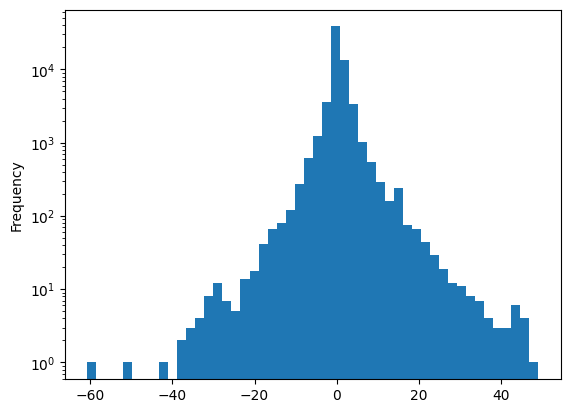

In [60]:
print(df["cate"].describe())
df["cate"].plot.hist(bins=50)
plt.yscale('log')

Average effect (incremental spend) is positive but exhibits large heterogenity.

### Who do we target, based on CATE

We mock up new (unseen) customers and choose who to apply the treatment. Say the cost of the campaign per customer is $1.5. We want to determine the decile of these customers to target on.

In [76]:
from sklearn.model_selection import train_test_split

df_mock, _ = train_test_split(
    df,
    train_size=1000,
    stratify=df[treat_flag1],
    random_state=42
)
df_mock = df_mock.reset_index(drop=True)

In [77]:
df_mock["cate"] = cf.effect(df_mock[pretreat_cols_psm])
df_mock = df_mock.sort_values(by="cate", ascending=False).reset_index(drop=True)

In [78]:
# cost per email sent
cost = 1.5

In [79]:
df_mock["decile"] = pd.qcut(
    df_mock["cate"],
    10,
    labels=False
)

In [80]:
df_mock.groupby("decile").agg({
    "cate": ["mean", "std"],
})

cate          
            mean       std
decile                    
0      -4.057242  3.100050
1      -0.769152  0.265481
2      -0.224719  0.089168
3      -0.034856  0.031644
4       0.078252  0.047908
5       0.275113  0.072361
6       0.543003  0.097020
7       1.001224  0.178554
8       2.050343  0.465947
9       6.987451  6.094445

Run campaign on top two deciles.

Check against ground truth:

In [81]:
for d in sorted(df_mock["decile"].unique()):

    sub = df_mock[df_mock["decile"] == d]

    effect = (
        sub[sub.segment1 == 1]["spend"].mean()
        -
        sub[sub.segment1 == 0]["spend"].mean()
    )

    print(f"Decile: {d}: {effect}")

Decile: 0: -0.9475609756097562
Decile: 1: 0.0
Decile: 2: 0.0
Decile: 3: 0.0
Decile: 4: 0.0
Decile: 5: 0.0
Decile: 6: 0.0
Decile: 7: 0.0
Decile: 8: 0.0
Decile: 9: 0.8407894736842106


Ground truth CATE by decile is actually less than the predicted ones. More modelling work may be needed.